# ***Multiclass Classification***

        What are the OneVsRestClassifier, OneVsOneClassifier?
        What are the core problems they solve?

        Some algorithms like LogisticRegression and SVC are naturally binary -
        they only know how to draw one line separating two classes. But we 
        often have 3,5 or 12 classes.

        OneVsRestClassifier and OneVsOneclassifier are metaestimators: 
        wrappers that take a binary classifier and a strategy, and turn it into
        a multiclass classifier by training many binary classifiers internally
        and combining their outputs.

        Many sklearn models: RandomForestClassifier, LogisticRegression(multi_class='multinomial'), 
        DecisionTreeClassifier already handle multiclass natively - we do not have to use OvO | OvR 
        Classifiers.

        These wrappers matter most for inherently binary algorithms like SVC or Perceptron.

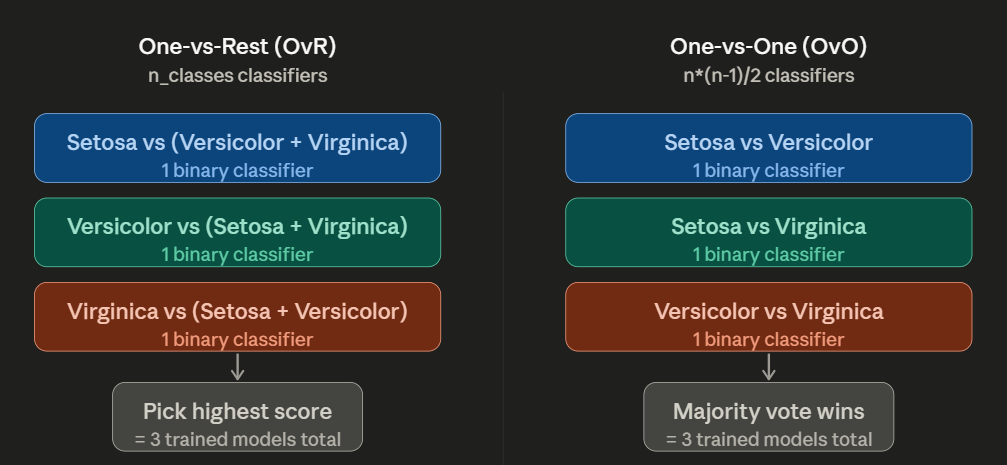


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("smart_grid_stability_augmented.csv")
df.shape

(60000, 14)

In [3]:
df.sample(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
36547,6.623314,4.816820,3.919480,9.816867,2.416115,-1.177756,-0.506886,-0.731472,0.311971,0.464983,0.723498,0.298742,0.016572,unstable
56900,3.315545,3.948092,2.278194,6.350933,2.904054,-0.579447,-1.573183,-0.751424,0.260947,0.845439,0.597836,0.767144,0.042951,unstable
37518,3.804356,1.307549,7.526816,7.061690,3.171430,-1.372001,-1.066662,-0.732767,0.128328,0.227621,0.886579,0.854499,0.045500,unstable
29849,4.158711,4.038803,6.586066,9.954180,4.567160,-1.466113,-1.228160,-1.872888,0.545887,0.906386,0.499750,0.231742,0.037304,unstable
46178,8.992297,3.851204,6.787957,5.517367,3.453403,-1.221218,-1.211435,-1.020750,0.833727,0.225979,0.267330,0.621896,0.043194,unstable
32268,1.690913,4.732536,6.443775,8.051360,3.962893,-1.707323,-1.062721,-1.192849,0.641018,0.986175,0.872294,0.550602,0.064240,unstable
47853,2.577338,2.724220,4.766831,3.053335,3.773472,-1.107890,-1.979726,-0.685856,0.212701,0.790318,0.713549,0.611949,0.035019,unstable
33095,5.005050,1.460080,7.584954,6.113331,4.208600,-1.097594,-1.525413,-1.585593,0.154558,0.964136,0.564927,0.229740,-0.027917,stable
4913,9.500851,9.739969,5.786393,7.288799,2.853673,-0.897874,-0.661042,-1.294756,0.960248,0.422586,0.760575,0.987393,0.091302,unstable
34131,7.291729,1.153307,6.479709,1.305038,4.063145,-1.900303,-1.598489,-0.564353,0.745317,0.082858,0.081728,0.305596,-0.029861,stable


        The raw dataset is binary | stabf: stable/unstable |
        To get a real multiclass case, we split the continuous stab
        column into 4 equal-sized bands using quartiles:

In [4]:
df["stab_class"] = pd.qcut(df['stab'], q=4,
                           labels=['very_stable', 'stable', 'unstable', 'very_unstable'])


In [5]:
df.sample(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf,stab_class
29483,0.833939,8.222458,4.555470,1.670608,3.921963,-1.634819,-1.084917,-1.202227,0.054038,0.422326,0.502975,0.517986,-0.032854,stable,very_stable
7786,4.752853,8.082357,5.000185,6.582326,4.354803,-1.420187,-1.814186,-1.120430,0.635143,0.144081,0.809505,0.768718,0.066341,unstable,very_unstable
1218,1.391291,0.894219,5.598584,6.900038,5.181189,-1.379557,-1.846106,-1.955526,0.741783,0.514507,0.325597,0.612594,-0.021976,stable,very_stable
4222,1.366931,8.177095,8.517865,5.182144,3.991578,-1.441544,-1.148882,-1.401152,0.521749,0.239509,0.381440,0.064216,-0.034453,stable,very_stable
36540,4.419855,9.378596,5.106516,1.041741,3.998944,-0.862285,-1.143124,-1.993535,0.742054,0.719801,0.243895,0.422169,0.007016,unstable,stable
6150,3.976186,1.747894,4.407637,9.494114,4.119537,-0.642848,-1.592779,-1.883910,0.618458,0.848045,0.852228,0.796403,0.023751,unstable,unstable
15733,1.925999,7.443705,6.821844,4.534880,3.979123,-0.703145,-1.349884,-1.926094,0.881965,0.496885,0.943475,0.321883,0.039753,unstable,unstable
17815,5.439539,2.460929,6.372255,0.557949,3.353578,-0.871692,-0.564005,-1.917881,0.994854,0.804168,0.121129,0.281766,0.005075,unstable,stable
59887,1.040731,9.871980,9.545592,8.754332,3.423061,-1.007191,-1.673956,-0.741914,0.607206,0.266640,0.156812,0.935708,0.010926,unstable,stable
26,5.895693,1.096302,1.311732,8.777868,4.069170,-1.063139,-1.374427,-1.631604,0.867791,0.141839,0.343262,0.711899,0.020088,unstable,unstable


    We drop the original continuous|binary target columns -
    they would leak information about the class we are trying
    to predict.

In [6]:
X = df.drop(columns=['stab', 'stabf', 'stab_class'])
y = df['stab_class']

print(X.columns.tolist())
print(X.shape, y.shape)

['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
(60000, 12) (60000,)


    Train|test|split:
    stratify=y keeps the class proportions identical in both train and test sets
    important since we want a fair multiclass comparison.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
y_train.value_counts()

Train size: (42000, 12)
Test size: (18000, 12)


stab_class
very_stable      10500
stable           10500
unstable         10500
very_unstable    10500
Name: count, dtype: int64

    Scale features:
    SVMs (base binary classifier in this case) are sensitive to feture scale.
    StandardScaler standardizes each feature to mean 0, std 1.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **OneVsRestClassifier**

For 4 classes, this trains 4 binary classifiers:
- very_stable vs rest
- stable vs rest
- unstable vs rest
- very unstable vs rest

Each sample gets a score from all 4: the highest score wins 

In [9]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

ovr_model = OneVsRestClassifier(SVC(kernel="linear", random_state=42))
ovr_model.fit(X_train_scaled, y_train)

print("Number of binary classifiers trained:", len(ovr_model.estimators_))
print("Classes:", ovr_model.classes_)

Number of binary classifiers trained: 4
Classes: ['stable' 'unstable' 'very_stable' 'very_unstable']


In [10]:
y_pred_ovr = ovr_model.predict(X_test_scaled)
y_pred_ovr[:10]

array(['very_unstable', 'very_stable', 'very_stable', 'very_stable',
       'very_stable', 'very_stable', 'very_stable', 'very_stable',
       'very_stable', 'very_unstable'], dtype='<U13')

**Evaluate OvR**

In [11]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== One-vs-Rest (OvR) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ovr))
print()
print(classification_report(y_test, y_pred_ovr))

=== One-vs-Rest (OvR) ===
Accuracy: 0.5193333333333333

               precision    recall  f1-score   support

       stable       0.32      0.13      0.19      4500
     unstable       0.45      0.21      0.29      4500
  very_stable       0.54      0.85      0.66      4500
very_unstable       0.58      0.88      0.70      4500

     accuracy                           0.52     18000
    macro avg       0.47      0.52      0.46     18000
 weighted avg       0.47      0.52      0.46     18000



In [12]:
import pandas as pd

cm_ovr = confusion_matrix(y_test, y_pred_ovr, labels=ovr_model.classes_)
pd.DataFrame(cm_ovr, index=ovr_model.classes_, columns=ovr_model.classes_)

,stable,unstable,very_stable,very_unstable
stable,600,754,2369,777
unstable,716,964,833,1987
very_stable,285,232,3826,157
very_unstable,272,192,78,3958


# **OneVsOneClassifier**

For 4 classes this trains n(n-1)/2 binary classifiers - one for every unique pair:

- very_stable vs stable 
- very_stable vs unstable 
- very_stable vs very_unstable 
- stable vs unstable 
- stable vs very_unstable
- unstable vs very_unstable

Each pairwise classifier votes for one of its two classes: 
the class with the most votes wins.

In [16]:
from sklearn.multiclass import OneVsOneClassifier

ovo_model = OneVsOneClassifier(SVC(kernel="linear", random_state=42))
ovo_model.fit(X_train_scaled, y_train)

print("Number of binary classifiers trained:", len(ovr_model.estimators_))
print("Classes", ovr_model.classes_)

Number of binary classifiers trained: 4
Classes ['stable' 'unstable' 'very_stable' 'very_unstable']


In [17]:
y_pred_ovo = ovo_model.predict(X_test_scaled)
y_pred_ovo[:10]

array(['very_unstable', 'stable', 'very_stable', 'very_stable',
       'very_stable', 'stable', 'very_stable', 'very_stable', 'stable',
       'very_unstable'], dtype=object)

**Evaluate OvO**

In [18]:
print("=== One-vs-One (OvO) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ovo))
print()
print(classification_report(y_test, y_pred_ovo))

=== One-vs-One (OvO) ===
Accuracy: 0.569

               precision    recall  f1-score   support

       stable       0.43      0.38      0.41      4500
     unstable       0.47      0.46      0.46      4500
  very_stable       0.67      0.69      0.68      4500
very_unstable       0.67      0.75      0.71      4500

     accuracy                           0.57     18000
    macro avg       0.56      0.57      0.56     18000
 weighted avg       0.56      0.57      0.56     18000



In [19]:
cm_ovo = confusion_matrix(y_test, y_pred_ovo, labels=ovo_model.classes_)
pd.DataFrame(cm_ovo, index=ovo_model.classes_, columns=ovo_model.classes_)

,stable,unstable,very_stable,very_unstable
stable,1716,1054,1240,490
unstable,1093,2070,278,1059
very_stable,976,353,3095,76
very_unstable,163,967,9,3361


### **Side by Side comparison**

Put both classification reports into one table so the per-class differences are obvious — especially for the two middle classes (`stable`, `unstable`), which sit on the boundary between extremes and are the hardest to separate.

In [20]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame({
    'OvR_f1': f1_score(y_test, y_pred_ovr, average=None, labels=ovr_model.classes_),
    'OvO_f1': f1_score(y_test, y_pred_ovo, average=None, labels=ovo_model.classes_),
}, index=ovr_model.classes_)

comparison['OvO_minus_OvR'] = comparison['OvO_f1'] - comparison['OvR_f1']
comparison

,OvR_f1,OvO_f1,OvO_minus_OvR
stable,0.188294,0.406250,0.217956
unstable,0.290274,0.462880,0.172606
very_stable,0.659314,0.678579,0.019265
very_unstable,0.695667,0.708623,0.012956


In [21]:
print(f"OvR overall accuracy: {accuracy_score(y_test, y_pred_ovr):.3f}  ({len(ovr_model.estimators_)} classifiers)")
print(f"OvO overall accuracy: {accuracy_score(y_test, y_pred_ovo):.3f}  ({len(ovo_model.estimators_)} classifiers)")

OvR overall accuracy: 0.519  (4 classifiers)
OvO overall accuracy: 0.569  (6 classifiers)


## Why this happens 

- **OvR** asks each class to fight *everyone else combined*. The two extreme classes
  (`very_stable`, `very_unstable`) are easy because they sit far from the pack.
  The two middle classes (`stable`, `unstable`) struggle — they're squeezed between
  neighbors on the stability spectrum, so a single "this vs everything" boundary
  can't isolate them well.
- **OvO** asks focused pairwise questions ("stable or unstable, ignoring everything else").
  This isolates the boundary between *adjacent, easily-confused* classes much better,
  which is why the middle classes usually see the biggest f1 improvement under OvO.
- The tradeoff: OvO trains more classifiers (6 vs 4 here). For datasets with **many**
  classes and **little** data per class (like the Bundesliga example from before),
  OvO's pairwise sub-problems can start from too little data and underperform —
  the opposite of what we see here.

**Rule of thumb:**
| Situation | Better choice |
|---|---|
| Few classes, plenty of data per class, classes on a continuum | OvO |
| Many classes, sparse data per class | OvR |
| Base estimator is already multiclass-native (RandomForest, native LogisticRegression) | Neither wrapper needed |